


<font color=red size=6>TECH CHALLENGE - FASE 2</font>
# Previsão de Qualidade de Vinhos (Classificação Binária)

In [ ]:
# 1. IMPORTAÇÃO DE BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# 2. CARREGAMENTO E INSPEÇÃO INICIAL DOS DADOS

df = pd.read_csv('WineQT.csv')
print("ANÁLISE INICIAL DOS DADOS")
print(f"\nShape: {df.shape}")
print(f"\nTipos:\n{df.dtypes}")

# Verificação de missing data
missing_data = df.isnull().sum().sum()
print(f"\nDados faltantes totais: {missing_data}")

print(f"\nEstatísticas descritivas:\n{df.describe().round(2)}")


ANÁLISE INICIAL DOS DADOS

Shape: (1143, 13)

Tipos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Dados faltantes totais: 0

Estatísticas descritivas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1143.00           1143.00      1143.00         1143.00   
mean            8.31              0.53         0.27            2.53   
std             1.75              0.18         0.20            1.36   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.5

In [ ]:
# 3. COMPREENSÃO DO PROBLEMA E DEFINIÇÃO DA VARIÁVEL ALVO

print("1. COMPREENSÃO DO PROBLEMA")
print("""
Contexto: O dataset WineQT contém análises físico-químicas de vinhos
tinto portugueses (variedade Vinho Verde). Cada amostra foi avaliada
por especialistas (enólogos) que atribuíram uma nota de 0 a 10.

Problema: Classificação binária para prever se um vinho é de Alta
Qualidade (nota >= 7) ou Baixa/Média Qualidade (nota < 7).

Tipo: Aprendizado Supervisionado de Classificação.

Variével Alvo: quality (nota de 0 a 10)
""")

# Aqui remover a coluna Id pois ela não tem influencia na classificação dos dados
df.drop('Id', axis=1, inplace=True)
print("Coluna 'Id' removida.")

# Transformação binária da variável alvo
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("\nDistribuição da variável alvo:")
print(df['quality_binary'].value_counts())
print(f"\nProporção:\n{df['quality_binary'].value_counts(normalize=True).round(4) * 100}")

1. COMPREENSÃO DO PROBLEMA

Contexto: O dataset WineQT contém análises físico-químicas de vinhos
tinto portugueses (variedade Vinho Verde). Cada amostra foi avaliada
por especialistas (enólogos) que atribuíram uma nota de 0 a 10.

Problema: Classificação binária para prever se um vinho é de Alta
Qualidade (nota >= 7) ou Baixa/Média Qualidade (nota < 7).

Tipo: Aprendizado Supervisionado de Classificação.

Variével Alvo: quality (nota de 0 a 10)

Coluna 'Id' removida.

Distribuição da variável alvo:
quality_binary
0    984
1    159
Name: count, dtype: int64

Proporção:
quality_binary
0    86.09
1    13.91
Name: proportion, dtype: float64


2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)


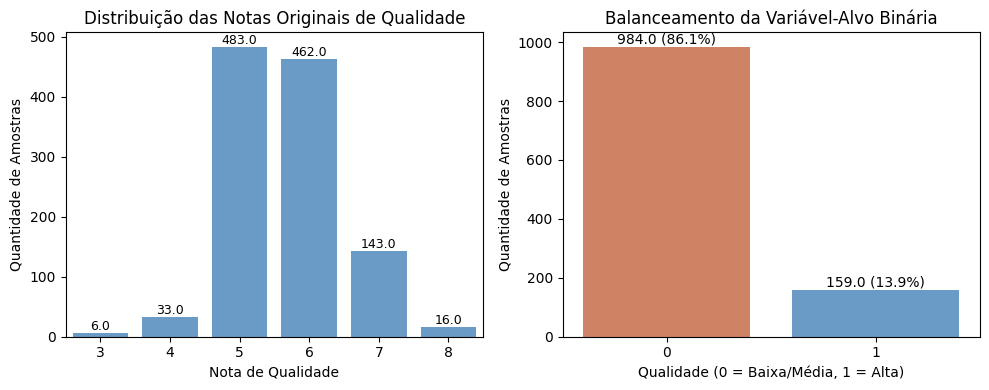


>>> Observação: O dataset é desbalanceado (~86% classe 0 vs ~14% classe 1).
# --- Balanceamento de Classes ---
O balanceamento de classes é um processo fundamental quando se lida com datasets
onde uma classe (majoritária) possui um número de amostras muito superior à outra
(minoritária). No nosso caso, a classe '0' (Baixa/Média Qualidade) é predominante
(~86%) e a classe '1' (Alta Qualidade) é minoritária (~14%).

Por que é necessário balancear?
Modelos de Machine Learning, quando treinados em dados desbalanceados, tendem a
se tornar viesados em favor da classe majoritária. Isso acontece porque o modelo
aprende que a melhor forma de minimizar o erro total é prever a classe majoritária
na maioria das vezes, ignorando a classe minoritária. Consequentemente, o modelo
terá uma alta acurácia (pois acerta a maioria), mas um péssimo recall e precisão
para a classe minoritária, que é geralmente a de maior interesse em muitos problemas
(ex: detecção de fraudes, doenças raras, vinhos de alta qu

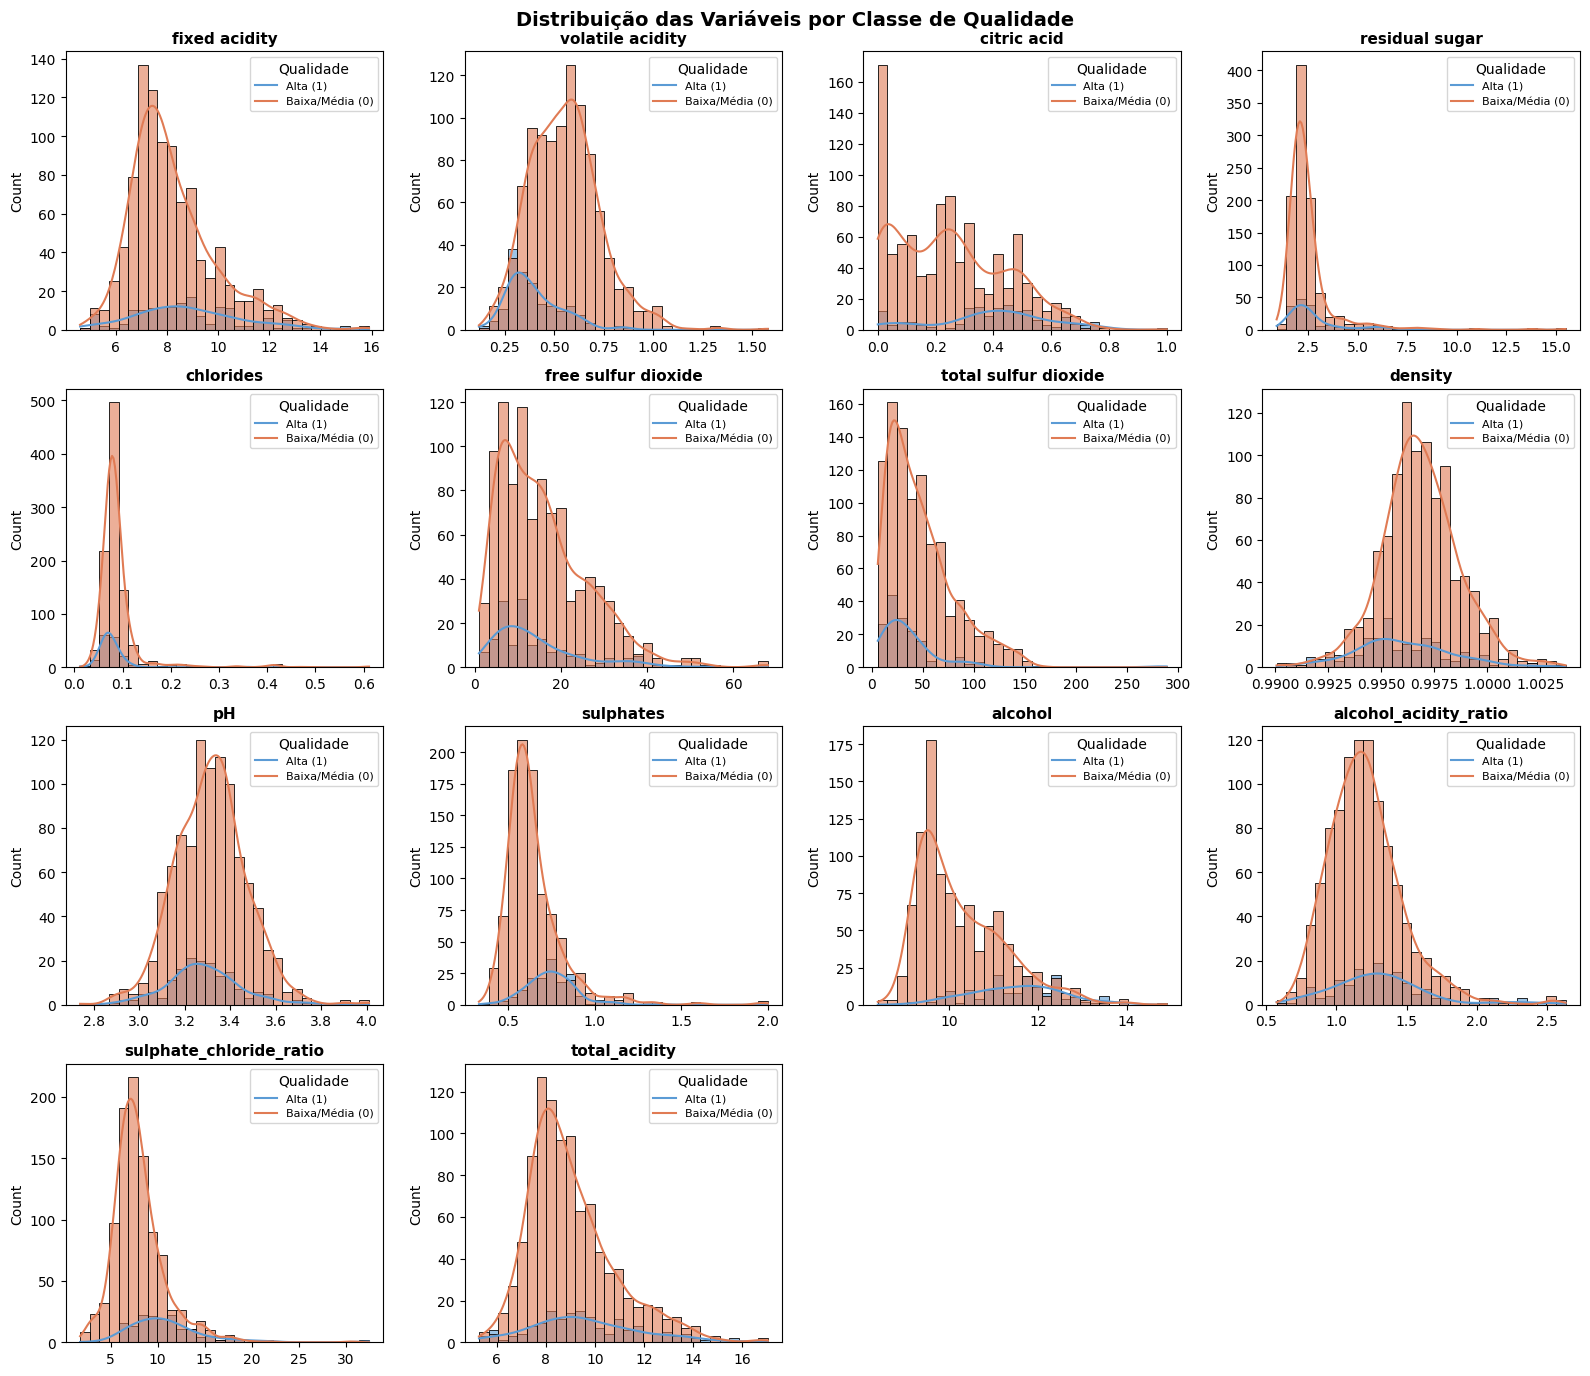


>>> alcohol e sulphates têm distribuições mais separadas entre as classes —
>>> isso indica boa capacidade preditiva!


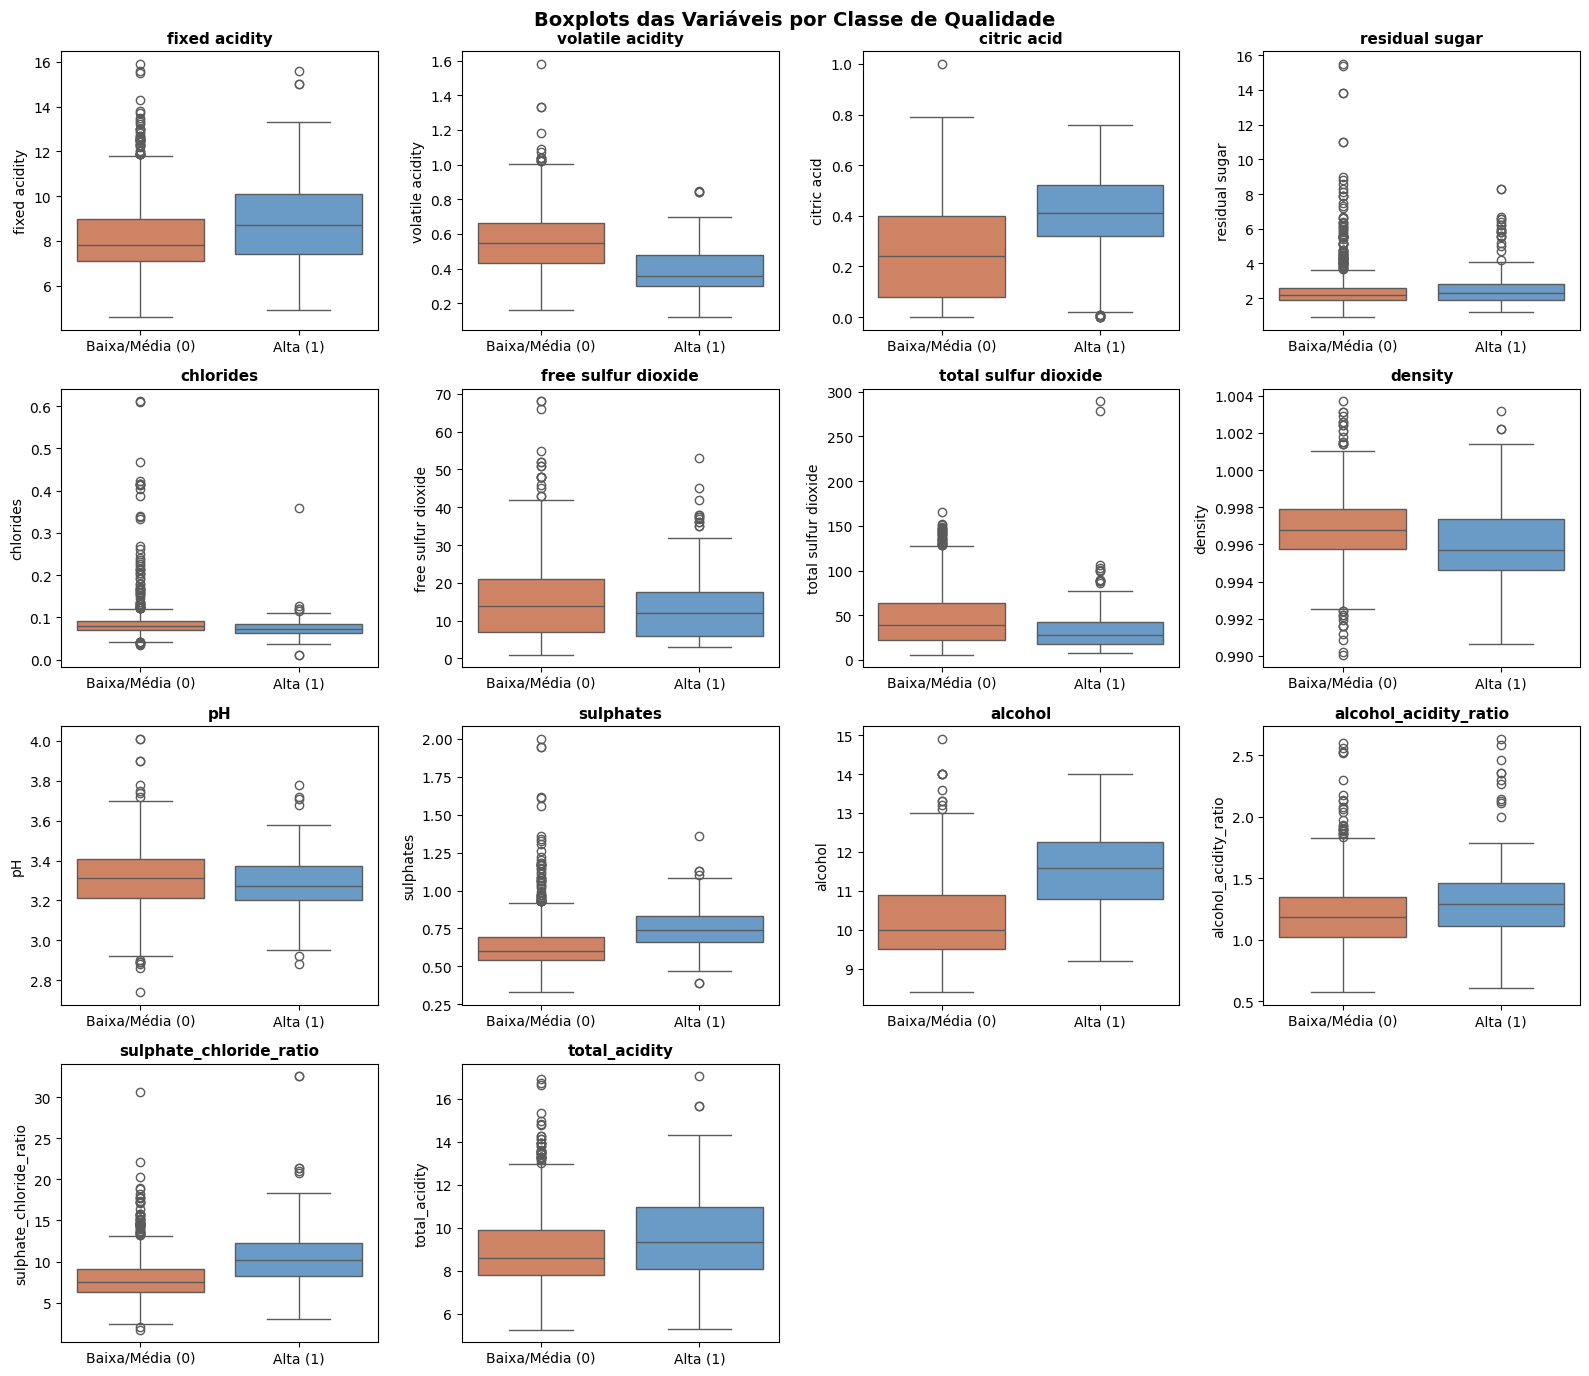


------------------------------------------------------------
Análise de Outliers (Método IQR)
------------------------------------------------------------
  fixed acidity               :   44 outliers (3.8%)
  volatile acidity            :   14 outliers (1.2%)
  citric acid                 :    1 outliers (0.1%)
  residual sugar              :  110 outliers (9.6%)
  chlorides                   :   77 outliers (6.7%)
  free sulfur dioxide         :   18 outliers (1.6%)
  total sulfur dioxide        :   40 outliers (3.5%)
  density                     :   36 outliers (3.1%)
  pH                          :   20 outliers (1.7%)
  sulphates                   :   43 outliers (3.8%)
  alcohol                     :   12 outliers (1.0%)
  alcohol_acidity_ratio       :   34 outliers (3.0%)
  sulphate_chloride_ratio     :   63 outliers (5.5%)
  total_acidity               :   44 outliers (3.8%)

>>> Foi decidido manter os outliers pois em dados de vinhos, amostras extremas
representam caracterís

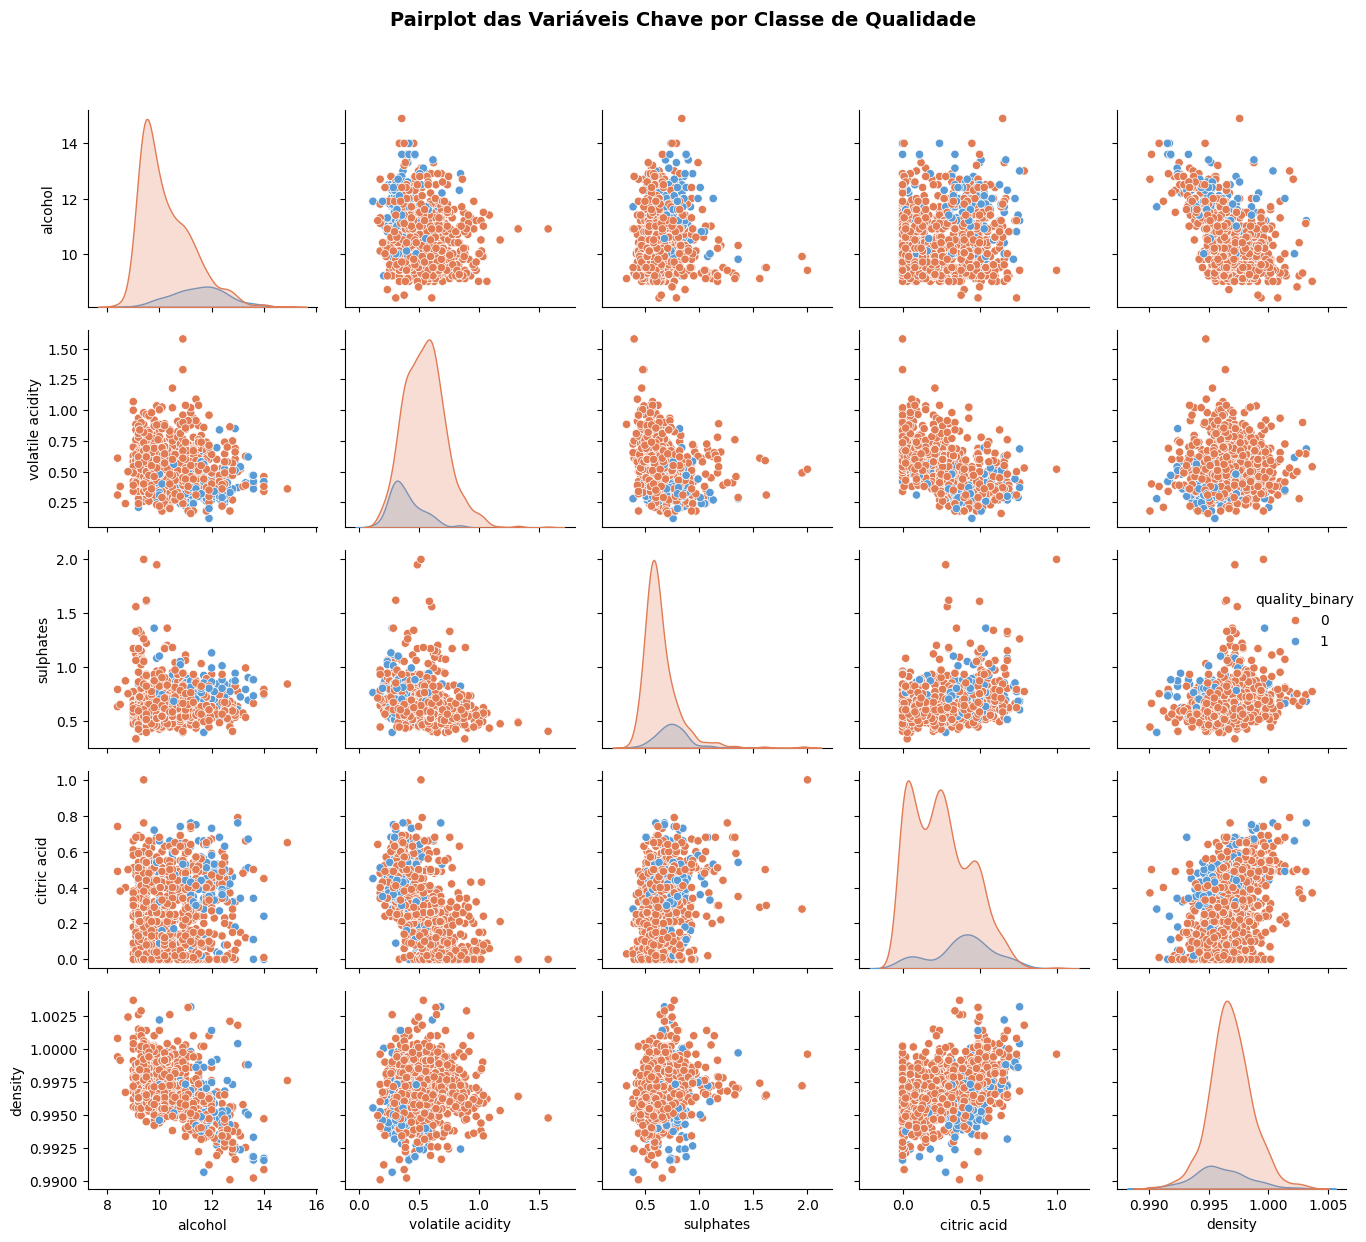


>>> Observação: Os pairplots mostram as distribuições de cada variável e as relações
>>> par-a-par, coloridas pela qualidade do vinho. Isso pode revelar padrões de agrupamento
>>> e interações entre as variáveis que são preditivas para a qualidade.

MATRIZ DE CORRELAÇÃO


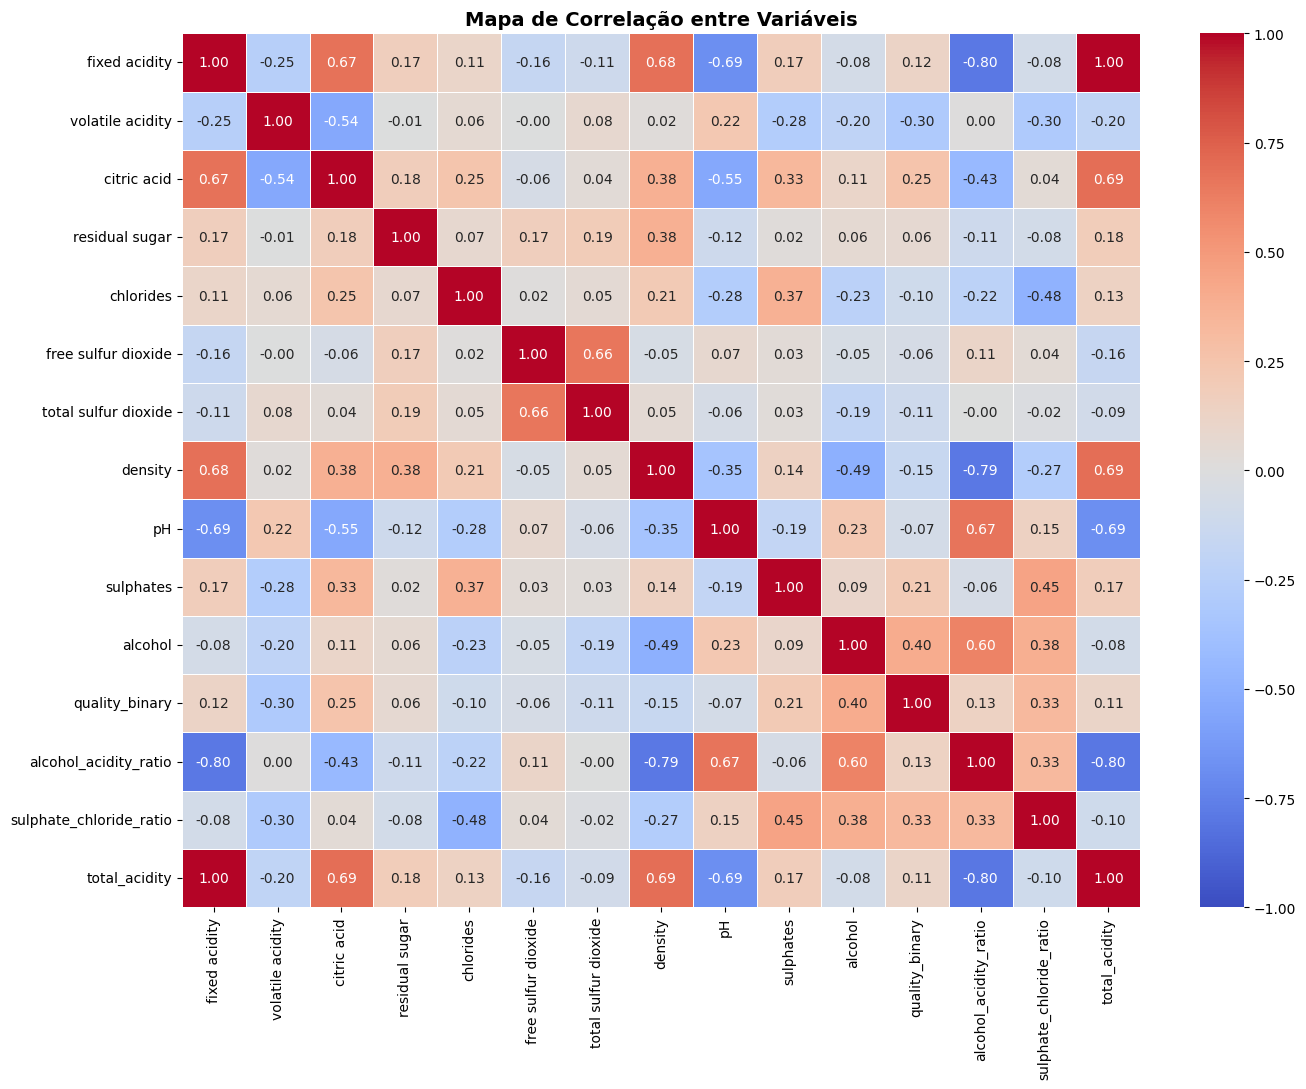

CORRELAÇÕES COM A QUALIDADE BINÁRIA (high_quality)
  alcohol                       : +0.4037
  sulphate_chloride_ratio       : +0.3271
  citric acid                   : +0.2511
  sulphates                     : +0.2080
  alcohol_acidity_ratio         : +0.1330
  fixed acidity                 : +0.1232
  total_acidity                 : +0.1140
  residual sugar                : +0.0641
  free sulfur dioxide           : -0.0560
  pH                            : -0.0733
  chlorides                     : -0.1040
  total sulfur dioxide          : -0.1134
  density                       : -0.1487
  volatile acidity              : -0.3045

>>> INTERPRETAÇÃO DAS CORRELAÇÕES MAIS RELEVANTES:

  1. alcohol (+0.40) — Correlação POSITIVA mais forte. Vinhos com maior
     teor alcoólico tendem a ter notas mais altas. Indicador de uva bem
     madura e mosto mais concentrado.

  2. volatile acidity (-0.30) — Correlação NEGATIVA forte. Alta acidez
     volátil (ácido acético) causa sabor de vinagre, p

In [ ]:
# 4. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

print("2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")




# Balancear as classes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax1 = sns.countplot(x='quality', data=df, ax=axes[0], color='#5B9BD5')
axes[0].set_title('Distribuição das Notas Originais de Qualidade')
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Quantidade de Amostras')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)

ax2 = sns.countplot(x='quality_binary', data=df, ax=axes[1], palette=['#E07B54', '#5B9BD5'])
axes[1].set_title('Balanceamento da Variável-Alvo Binária')
axes[1].set_xlabel('Qualidade (0 = Baixa/Média, 1 = Alta)')
axes[1].set_ylabel('Quantidade de Amostras')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()} ({(p.get_height()/len(df))*100:.1f}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('class_balance.png', bbox_inches='tight')
plt.show()

print("\n>>> Observação: O dataset é desbalanceado (~86% classe 0 vs ~14% classe 1).")
print("""# --- Balanceamento de Classes ---
O balanceamento de classes é um processo fundamental quando se lida com datasets
onde uma classe (majoritária) possui um número de amostras muito superior à outra
(minoritária). No nosso caso, a classe '0' (Baixa/Média Qualidade) é predominante
(~86%) e a classe '1' (Alta Qualidade) é minoritária (~14%).

Por que é necessário balancear?
Modelos de Machine Learning, quando treinados em dados desbalanceados, tendem a
se tornar viesados em favor da classe majoritária. Isso acontece porque o modelo
aprende que a melhor forma de minimizar o erro total é prever a classe majoritária
na maioria das vezes, ignorando a classe minoritária. Consequentemente, o modelo
terá uma alta acurácia (pois acerta a maioria), mas um péssimo recall e precisão
para a classe minoritária, que é geralmente a de maior interesse em muitos problemas
(ex: detecção de fraudes, doenças raras, vinhos de alta qualidade).

O objetivo é evitar que o modelo classifique indevidamente vinhos de alta qualidade
como sendo de baixa/média qualidade, simplesmente por ter poucos exemplos da classe
'1' durante o treinamento. Técnicas como o SMOTE (Synthetic Minority Over-sampling
Technique) serão aplicadas na fase de pré-processamento para criar amostras sintéticas
da classe minoritária, ajudando o modelo a aprender melhor as características desta classe.
print(">>> Isso será tratado na etapa de pré-processamento com SMOTE.


""")

# Realizar histograma da distribuição das variáveis

print("HISTOGRAMA DAS DISTRIBUIÇÕES DAS VARIÁVEIS")

features = df.drop(columns=['quality', 'quality_binary']).columns.tolist()
n_features = len(features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='quality_binary', kde=True, ax=axes[i],
                 palette=['#E07B54', '#5B9BD5'], alpha=0.6, bins=30)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Qualidade', labels=['Alta (1)', 'Baixa/Média (0)'], fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

print("\n>>> alcohol e sulphates têm distribuições mais separadas entre as classes —")
print(">>> isso indica boa capacidade preditiva!")

# Realizar Boxplots para detecção de outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

# Criar coluna categórica para evitar problemas com palette
df['qualidade_label'] = df['quality_binary'].map({0: 'Baixa/Média (0)', 1: 'Alta (1)'})

for i, col in enumerate(features):
    # Usar paleta simples como lista de cores
    bp = sns.boxplot(data=df, x='qualidade_label', y=col, ax=axes[i],
                     palette=['#E07B54', '#5B9BD5'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

# Remover coluna auxiliar criada
df.drop('qualidade_label', axis=1, inplace=True)

# Análise quantitativa de outliers (IQR)
print("\n" + "-" * 60)
print("Análise de Outliers (Método IQR)")
print("-" * 60)
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary[col] = n_out
    print(f"  {col:<28}: {n_out:>4} outliers ({pct_out:.1f}%)")

print("""
>>> Foi decidido manter os outliers pois em dados de vinhos, amostras extremas
representam características reais (ex: vinhos de safras excepcionais),
não erros de medição. Modelos baseados em árvore (RF, XGBoost) são
robustos a outliers. Para RL e SVM, o impacto é mitigado pela
padronização dos dados.
""")

# Pairplot para visualização de relações entre variáveis

print("PAIRPLOTS PARA ANÁLISE DE RELAÇÕES ENTRE VARIÁVEIS")


# Incluindo a variável alvo 'quality_binary' para cores

selected_features_for_pairplot = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'quality_binary']
df_pairplot = df[selected_features_for_pairplot]

sns.pairplot(df_pairplot, hue='quality_binary', palette=['#E07B54', '#5B9BD5'], diag_kind='kde')
plt.suptitle('Pairplot das Variáveis Chave por Classe de Qualidade', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar layout para não sobrepor o título
plt.savefig('pairplot_selected_features.png', bbox_inches='tight')
plt.show()

print("""
>>> Observação: Os pairplots mostram as distribuições de cada variável e as relações
>>> par-a-par, coloridas pela qualidade do vinho. Isso pode revelar padrões de agrupamento
>>> e interações entre as variáveis que são preditivas para a qualidade.
""")

# Matriz de correlação
print("MATRIZ DE CORRELAÇÃO")

plt.figure(figsize=(14, 11))
corr_matrix = df.drop(columns=['quality']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Mapa de Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Interpretação das correlações com a qualidade
print("CORRELAÇÕES COM A QUALIDADE BINÁRIA (high_quality)")

corr_with_target = corr_matrix['quality_binary'].drop('quality_binary').sort_values(ascending=False)
for feat, val in corr_with_target.items():
    print(f"  {feat:<30}: {val:+.4f}")

print("""
>>> INTERPRETAÇÃO DAS CORRELAÇÕES MAIS RELEVANTES:

  1. alcohol (+0.40) — Correlação POSITIVA mais forte. Vinhos com maior
     teor alcoólico tendem a ter notas mais altas. Indicador de uva bem
     madura e mosto mais concentrado.

  2. volatile acidity (-0.30) — Correlação NEGATIVA forte. Alta acidez
     volátil (ácido acético) causa sabor de vinagre, prejudicando a
     qualidade. É um dos principais indicadores de contaminação na
     fermentação.

  3. sulphates (+0.25) — Correlação POSITIVA moderada. Sulfatos atuam
     como conservantes e antimicrobianos. Em níveis moderados,
     contribuem positivamente para a qualidade.

  4. citric acid (+0.21) — Correlação POSITIVA moderada. Ácido cítrico
     adiciona frescor e equilíbrio ao sabor do vinho.

  5. density (-0.15) — Correlação NEGATIVA moderada. Maior densidade
     geralmente indica mais açúcar residual e menos álcool, associado
     a qualidade menor.

  NOTA: A correlação negativa mais forte é com volatile acidity (-0.30),
  NÃO com citric acid (que tem correlação positiva de +0.21).
""")

In [ ]:
# 5. FEATURE ENGINEERING

print("3. PRÉ-PROCESSAMENTO — FEATURE ENGINEERING")
print("\n--- POR QUE FEATURE ENGINEERING? ---")
print("O Feature Engineering é crucial para melhorar o desempenho dos modelos de Machine Learning. Ele envolve a criação de novas variáveis (features) a partir das features existentes ou a transformação delas, com o objetivo de:\n  1. Capturar relações e interações mais complexas nos dados que os modelos talvez não consigam aprender sozinhos.\n  2. Simplificar a representação dos dados, tornando padrões mais evidentes.\n  3. Incorporar conhecimento de domínio (neste caso, sobre vinhos) para criar features mais significativas e preditivas.\nIsso pode levar a modelos mais precisos, robustos e com melhor poder de generalização.\n")




# Ratio álcool / acidez total — captura equilíbrio entre força alcoólica e acidez
df['alcohol_acidity_ratio'] = df['alcohol'] / (df['fixed acidity'] + df['volatile acidity'] + 1e-6)


# Ratio sulfatos / cloretos — mede equilíbrio entre conservantes (bons) e sal (ruim)
df['sulphate_chloride_ratio'] = df['sulphates'] / (df['chlorides'] + 1e-6)


# Total de acidez — soma das três componentes ácidas
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']
# Explicação: A acidez total é um fator crítico na estrutura e sabor do vinho. Ao somar as diferentes formas de acidez
# (fixa, volátil e cítrica), criamos uma medida abrangente que pode oferecer uma visão mais completa do perfil ácido
# do vinho do que as componentes individuais. Vinhos com acidez total equilibrada tendem a ser mais apreciados.

print("3 novas features criadas:")
print("\nalcohol_acidity_ratio: razão álcool/acidez total")
print("""\nExplicação: Esta feature visa capturar a relação entre o teor alcoólico do vinho e sua acidez total.
# Um equilíbrio adequado entre álcool (que confere corpo e doçura) e acidez (que traz frescor e vivacidade)
# é fundamental para a percepção da qualidade do vinho. Uma razão mais alta pode indicar um vinho mais
# 'equilibrado' ou 'potente', enquanto uma razão baixa pode sugerir um vinho 'ácido' ou 'fraco'.""")
print("\nsulphate_chloride_ratio: razão sulfatos/cloretos")
print("""\nExplicação: Sulfatos são frequentemente adicionados como conservantes e antioxidantes, contribuindo positivamente
# para a estabilidade e qualidade do vinho. Cloretos, por outro lado, podem estar associados a salinidade e
# características indesejáveis em excesso. Esta razão busca quantificar o balanço entre esses dois componentes,
# onde um valor mais alto pode ser indicativo de um vinho mais bem conservado e com menos influência salina.""")
print("\ntotal_acidity: soma das acidezes (fixa + volátil + cítrica)")
print("""\nExplicação: Sulfatos são frequentemente adicionados como conservantes e antioxidantes, contribuindo positivamente
# para a estabilidade e qualidade do vinho. Cloretos, por outro lado, podem estar associados a salinidade e
# características indesejáveis em excesso. Esta razão busca quantificar o balanço entre esses dois componentes,
# onde um valor mais alto pode ser indicativo de um vinho mais bem conservado e com menos influência salina.""")

3. PRÉ-PROCESSAMENTO — FEATURE ENGINEERING

--- POR QUE FEATURE ENGINEERING? ---
O Feature Engineering é crucial para melhorar o desempenho dos modelos de Machine Learning. Ele envolve a criação de novas variáveis (features) a partir das features existentes ou a transformação delas, com o objetivo de:
  1. Capturar relações e interações mais complexas nos dados que os modelos talvez não consigam aprender sozinhos.
  2. Simplificar a representação dos dados, tornando padrões mais evidentes.
  3. Incorporar conhecimento de domínio (neste caso, sobre vinhos) para criar features mais significativas e preditivas.
Isso pode levar a modelos mais precisos, robustos e com melhor poder de generalização.

3 novas features criadas:

alcohol_acidity_ratio: razão álcool/acidez total

Explicação: Esta feature visa capturar a relação entre o teor alcoólico do vinho e sua acidez total. 
# Um equilíbrio adequado entre álcool (que confere corpo e doçura) e acidez (que traz frescor e vivacidade) 
# é fund

In [ ]:
# 6. PRÉ-PROCESSAMENTO — PADRONIZAÇÃO E DIVISÃO

print("PADRONIZAÇÃO E DIVISÃO TREINO/TESTE")

# Separar features e target
features = df.drop(columns=['quality', 'quality_binary']).columns.tolist()
X = df[features].values
y = df['quality_binary'].values

# Split TREINO/TESTE com estratificação (ANTES do scaler e SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporção no treino: {np.bincount(y_train) / len(y_train)}")
print(f"Proporção no teste:  {np.bincount(y_test) / len(y_test)}")

# Pipeline: StandardScaler + SMOTE (apenas no treino)
# NOTA: O scaler é FITADO apenas no treino e TRANSFORMADO no teste,
# evitando vazamento de dados.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nApós SMOTE — treino: {X_train_res.shape[0]} amostras")
print(f"Distribuição após SMOTE: {np.bincount(y_train_res)}")

PADRONIZAÇÃO E DIVISÃO TREINO/TESTE
Treino: 914 amostras
Teste:  229 amostras

Proporção no treino: [0.86105033 0.13894967]
Proporção no teste:  [0.86026201 0.13973799]

Após SMOTE — treino: 1574 amostras
Distribuição após SMOTE: [787 787]


In [ ]:
# 7. DESENVOLVIMENTO DOS MODELOS

print("4. DESENVOLVIMENTO DOS MODELOS")

print("""Por que é necessário testar modelos diferentes de machine learning, em vez de apenas um único melhor método?
Por que não existe almoço grátis em aprendizado de máquina:
Nenhum método domina todos os outros em todos os conjuntos de dados possíveis.""")
print("\n""""Vamos trabalhar com os seguintes modelos:

Logistic Regression
Random Forest
XG Boosting
Support Vector Machine (SVM)
""")
print("\nRegressão Logística")
print("""prevê a probabilidade de algo acontecer (sim/não, compra/não compra).
O algoritmo encontra uma linha que separa duas classes e converte essa separação em probabilidade usando a função sigmoid.
É simples, rápido, interpretável e fornece probabilidades úteis para decisões. Como estamos deixando a variavel target binária servirá bem.
Ideal quando as classes são razoavelmente separáveis.""")
print("\nRandom Forest")
print("""O algoritmo cria múltiplas árvores de decisão, cada uma treinada com dados ligeiramente diferentes e depois combina suas previsões.
Funciona bem porque reduz erros ao não depender de uma única árvore, é resistente ao overfitting e lida bem com dados complexos.
É simples, rápido e um dos modelos mais usados na prática.""")
print("\nXG Boosting")
print("""Treina árvores de decisão sequencialmente, onde cada nova árvore corrige os erros da anterior.
Usa gradientes para otimizar uma função de perda e adiciona regularização para evitar overfitting
Funciona excepcionalmente bem porque combina velocidade, precisão e flexibilidade""")
print("\nSVM")
print("""Modelo que encontra a melhor linha (ou superfície em múltiplas dimensões) para separar duas classes com a maior margem possível entre elas.
Funciona bem tanto para classificação quanto para regressão.Funciona excepcionalmente bem porque maximiza a separação entre classes,
é robusto contra outliers e funciona bem em espaços de alta dimensionalidade.
Ideal para problemas com dados bem estruturados com é o caso do WineQT.csv e quando você precisa de decisões claras e interpretáveis""")

4. DESENVOLVIMENTO DOS MODELOS
Por que é necessário testar modelos diferentes de machine learning, em vez de apenas um único melhor método?
Por que não existe almoço grátis em aprendizado de máquina:
Nenhum método domina todos os outros em todos os conjuntos de dados possíveis.

Vamos trabalhar com os seguintes modelos:

Logistic Regression
Random Forest
XG Boosting
Support Vector Machine (SVM)


Regressão Logística
prevê a probabilidade de algo acontecer (sim/não, compra/não compra).
O algoritmo encontra uma linha que separa duas classes e converte essa separação em probabilidade usando a função sigmoid.
É simples, rápido, interpretável e fornece probabilidades úteis para decisões. Como estamos deixando a variavel target binária servirá bem.
Ideal quando as classes são razoavelmente separáveis.

Random Forest
O algoritmo cria múltiplas árvores de decisão, cada uma treinada com dados ligeiramente diferentes e depois combina suas previsões.
Funciona bem porque reduz erros ao não depende

In [ ]:
models = {}

# Modelo 1: Regressão Logística
print("\n--- Regressão Logística ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
models['Regressão Logística'] = (log_reg, y_pred_lr, y_proba_lr)
print(f"Acurácia: {accuracy_score(y_test, y_pred_lr):.4f}")

# Modelo 2: Random Forest
print("\n--- Random Forest ---")
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, min_samples_leaf=2)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
models['Random Forest'] = (rf, y_pred_rf, y_proba_rf)
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")

# Modelo 4: XGBoost
print("\n--- XGBoost ---")
xgb_model = xgb.XGBClassifier(
    random_state=42, use_label_encoder=False, eval_metric='logloss',
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=6.2  # ≈ 86/14 para compensar desbalanceamento
)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
models['XGBoost'] = (xgb_model, y_pred_xgb, y_proba_xgb)
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")

# Modelo 5: SVM
print("\n--- SVM (RBF Kernel) ---")
svm = SVC(random_state=42, probability=True, C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
models['SVM'] = (svm, y_pred_svm, y_proba_svm)
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")


--- Regressão Logística ---
Acurácia: 0.7817

--- Random Forest ---
Acurácia: 0.8908

--- XGBoost ---
Acurácia: 0.8865

--- SVM (RBF Kernel) ---
Acurácia: 0.8690


5. AVALIAÇÃO — VALIDAÇÃO CRUZADA (5 folds)
Regressão Logística       F1 macro: 0.8296 ± 0.0161
Random Forest             F1 macro: 0.9332 ± 0.0157
XGBoost                   F1 macro: 0.9318 ± 0.0142
SVM                       F1 macro: 0.9427 ± 0.0028


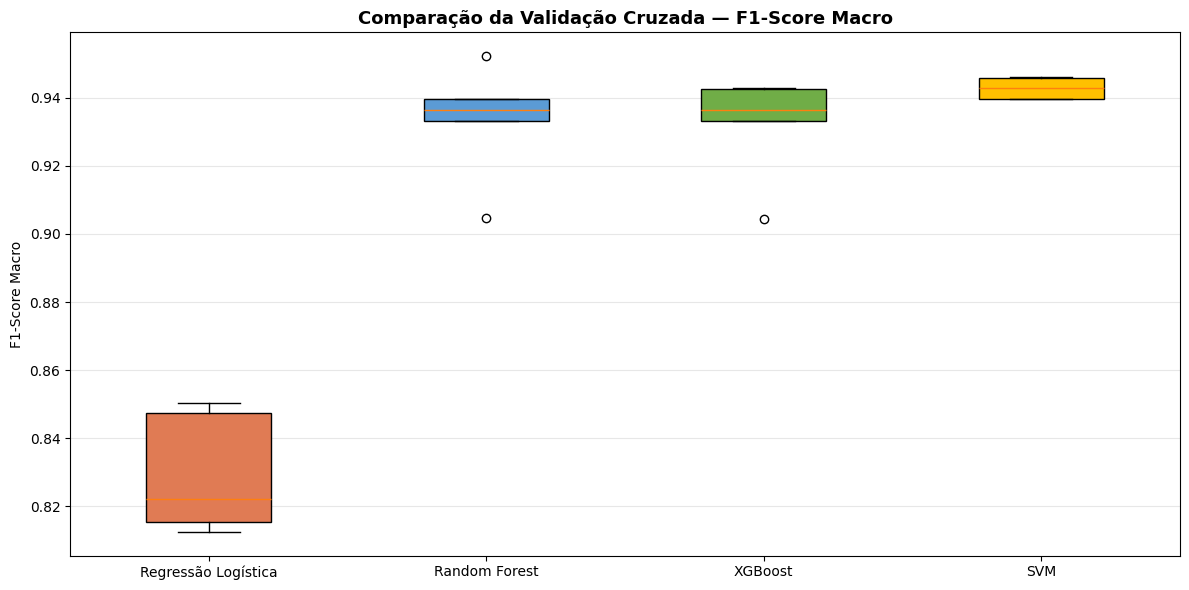

In [ ]:
# 8. VALIDAÇÃO CRUZADA

print("5. AVALIAÇÃO — VALIDAÇÃO CRUZADA (5 folds)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, (model, _, _) in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name:<25} F1 macro: {scores.mean():.4f} \u00b1 {scores.std():.4f}")

plt.figure(figsize=(12, 6))
bp = plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)

colors_box = ['#E07B54', '#5B9BD5', '#70AD47', '#FFC000', '#92D050']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
plt.title('Comparação da Validação Cruzada — F1-Score Macro', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score Macro')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

In [ ]:
# 9. AVALIAÇÃO DETALHADA DOS MODELOS

print("5. AVALIAÇÃO — MÉTRICAS NO CONJUNTO DE TESTE")

metrics_list = []
for name, (_, y_pred, y_proba) in models.items():
    metrics = {
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precision (classe 1)': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'Recall (classe 1)': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'F1-Score (classe 1)': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    metrics_list.append(metrics)

results_df = pd.DataFrame(metrics_list).set_index('Modelo')
print("\nTabela Comparativa de Desempenho:")
print(results_df.round(4).to_string())

5. AVALIAÇÃO — MÉTRICAS NO CONJUNTO DE TESTE

Tabela Comparativa de Desempenho:
                     Acurácia  Precision (classe 1)  Recall (classe 1)  F1-Score (classe 1)  ROC-AUC
Modelo                                                                                              
Regressão Logística    0.7817                0.3448             0.6250               0.4444   0.8457
Random Forest          0.8908                0.6000             0.6562               0.6269   0.8983
XGBoost                0.8865                0.5833             0.6562               0.6176   0.8793
SVM                    0.8690                0.5312             0.5312               0.5312   0.8660


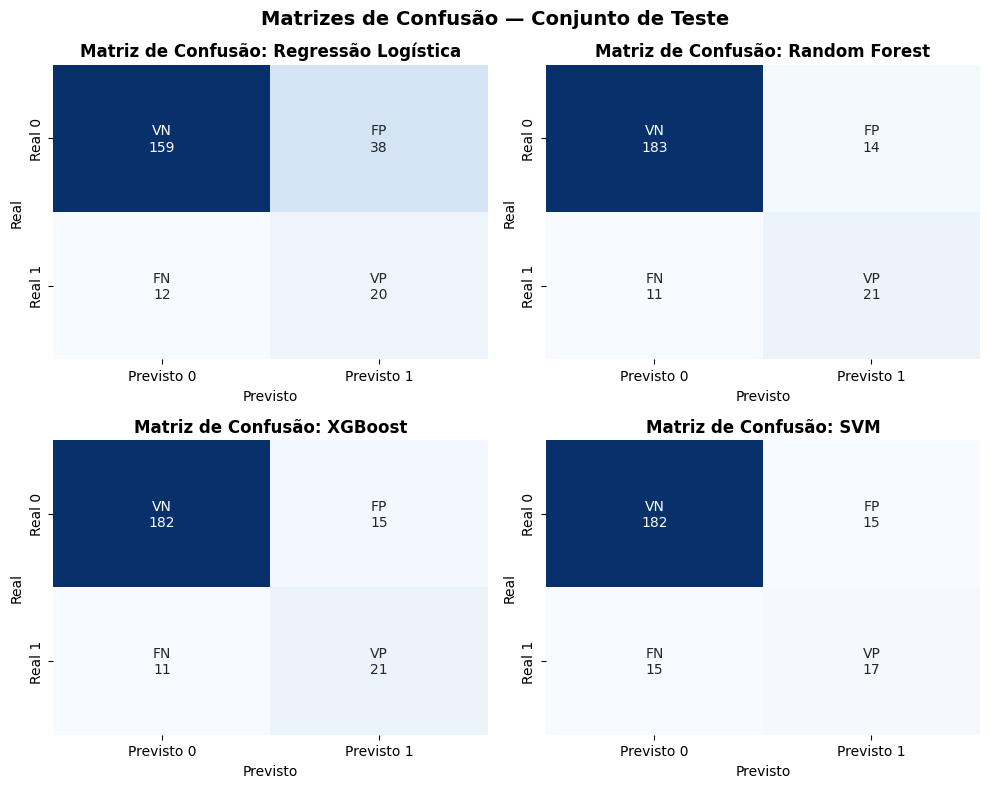

In [ ]:
# 10. MATRIZES DE CONFUSÃO

# Ajustar o grid de subplots para acomodar todos os modelos
n_models = len(models)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols # Calcular o número de linhas necessário

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for idx, (name, (_, y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    labels = np.array([f'VN\n{cm[0,0]}', f'FP\n{cm[0,1]}',
                       f'FN\n{cm[1,0]}', f'VP\n{cm[1,1]}']).reshape(2, 2)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])
    axes[idx].set_title(f'Matriz de Confusão: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Previsto')
    axes[idx].set_ylabel('Real')

# Ocultar subplots vazios, se houver
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

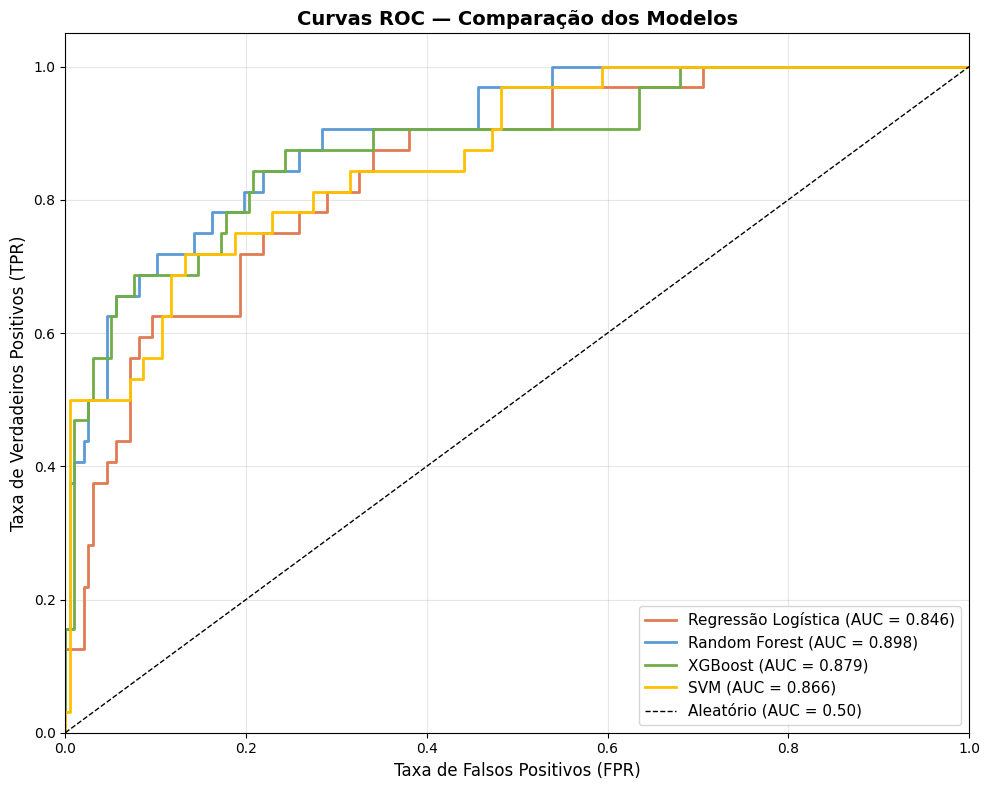


--- ANÁLISE DAS CURVAS ROC ---

A curva ROC (Receiver Operating Characteristic) e a Área sob a Curva (AUC)
são métricas cruciais para avaliar o desempenho de modelos de classificação binária,
especialmente em conjuntos de dados desbalanceados. A AUC representa a probabilidade
de o classificador ranquear uma instância positiva aleatória mais alta do que uma
negativa aleatória. Quanto mais próximo de 1, melhor o modelo distingue as classes.

INTERPRETAÇÃO DOS RESULTADOS DA AUC:
  - Regressão Logística: AUC = 0.846
  - Random Forest: AUC = 0.898
  - XGBoost: AUC = 0.879
  - SVM: AUC = 0.866

Observações:
  - Um valor de AUC próximo de 0.5 indica um classificador aleatório (linha pontilhada preta).
  - Todos os modelos apresentaram AUCs significativamente maiores que 0.5, indicando bom poder preditivo.
  - O modelo Random Forest obteve a maior AUC (0.898), seguido de perto pelo XGBoost (0.879) e SVM (0.866).
  - A Regressão Logística teve a menor AUC entre os modelos avaliados (0.846), em

In [ ]:
# 11. CURVAS ROC

plt.figure(figsize=(10, 8))
# Atualizando a lista de cores para incluir o novo modelo
colors_roc = ['#E07B54', '#5B9BD5', '#70AD47', '#FFC000', '#92D050'] # Adicionada uma nova cor

for (name, (_, _, y_proba)), color in zip(models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — Comparação dos Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

print("\n--- ANÁLISE DAS CURVAS ROC ---")
print("\nA curva ROC (Receiver Operating Characteristic) e a Área sob a Curva (AUC)")
print("são métricas cruciais para avaliar o desempenho de modelos de classificação binária,")
print("especialmente em conjuntos de dados desbalanceados. A AUC representa a probabilidade")
print("de o classificador ranquear uma instância positiva aleatória mais alta do que uma")
print("negativa aleatória. Quanto mais próximo de 1, melhor o modelo distingue as classes.")

print("\nINTERPRETAÇÃO DOS RESULTADOS DA AUC:")
for name, (_, _, y_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    print(f"  - {name}: AUC = {roc_auc:.3f}")

print("\nObservações:")
print("  - Um valor de AUC próximo de 0.5 indica um classificador aleatório (linha pontilhada preta).")
print("  - Todos os modelos apresentaram AUCs significativamente maiores que 0.5, indicando bom poder preditivo.")
print("  - O modelo Random Forest obteve a maior AUC (0.898), seguido de perto pelo XGBoost (0.879) e SVM (0.866).")
print("  - A Regressão Logística teve a menor AUC entre os modelos avaliados (0.846), embora ainda seja um resultado razoável.")
print("  - Modelos com curvas ROC que se aproximam mais do canto superior esquerdo são considerados melhores, pois indicam")
print("    altas taxas de verdadeiros positivos (TPR) com baixas taxas de falsos positivos (FPR).")
print("  - A proximidade entre as curvas de Random Forest, XGBoost e SVM sugere um desempenho similarmente forte para a tarefa de classificação.")

6. INTERPRETAÇÃO DOS RESULTADOS

--- IMPORTÂNCIA DAS FEATURES — RANDOM FOREST ---
  alcohol                             0.2015
  sulphates                           0.1182
  citric acid                         0.1154
  volatile acidity                    0.0988
  sulphate_chloride_ratio             0.0786
  total sulfur dioxide                0.0532
  fixed acidity                       0.0513
  total_acidity                       0.0480
  density                             0.0473
  alcohol_acidity_ratio               0.0431
  residual sugar                      0.0407
  pH                                  0.0385
  free sulfur dioxide                 0.0337
  chlorides                           0.0315


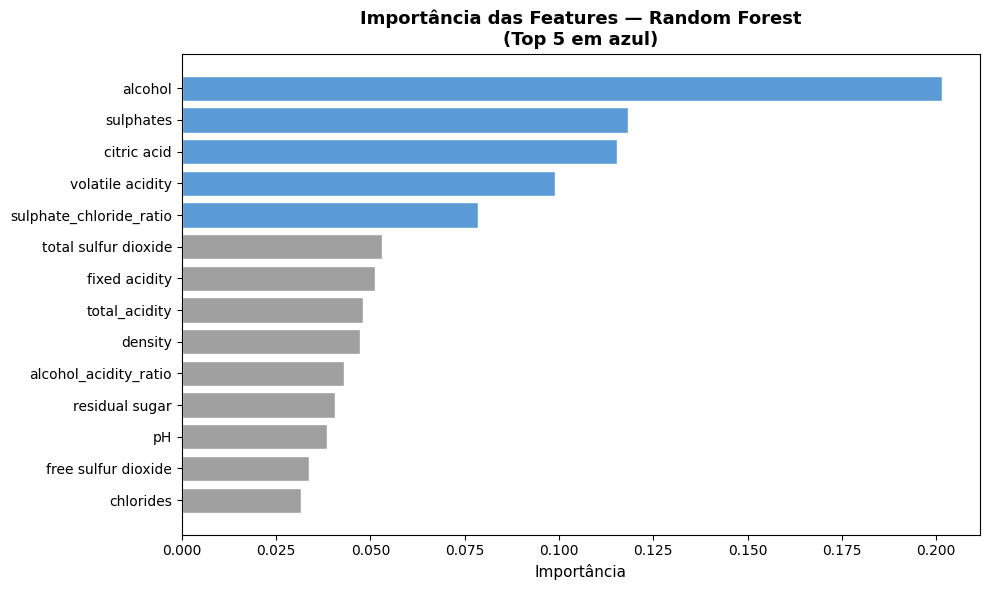


--- COEFICIENTES DA REGRESSÃO LOGÍSTICA ---
(Positivo → favorece Alta Qualidade | Negativo → desfavorece)
  total sulfur dioxide                -0.6563
  volatile acidity                    -0.4051
  alcohol_acidity_ratio               -0.3492
  chlorides                           -0.2325
  density                             -0.1752
  pH                                  -0.1149
  fixed acidity                       -0.0693
  total_acidity                       -0.0370
  free sulfur dioxide                 +0.1692
  residual sugar                      +0.2741
  sulphate_chloride_ratio             +0.3446
  sulphates                           +0.4985
  citric acid                         +0.6416
  alcohol                             +1.2500


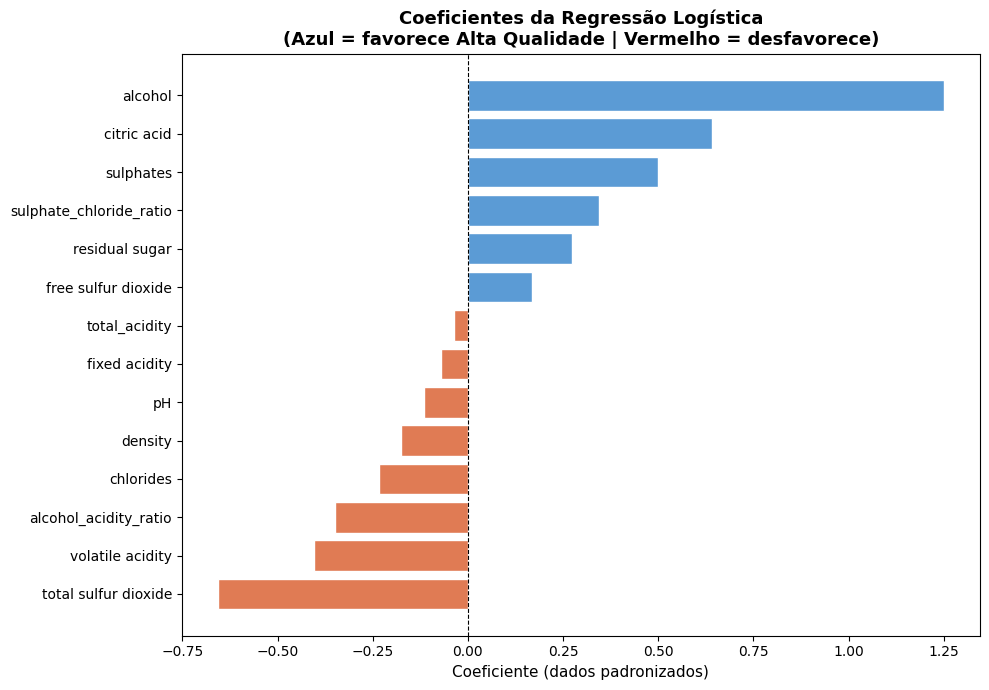

In [ ]:
# 12. INTERPRETAÇÃO DOS RESULTADOS


print("6. INTERPRETAÇÃO DOS RESULTADOS")


# 12.1 Importância das Features (Random Forest)
feature_names = features
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\n--- IMPORTÂNCIA DAS FEATURES — RANDOM FOREST ---")
for feat, imp in rf_importance.items():
    print(f"  {feat:<35} {imp:.4f}")

plt.figure(figsize=(10, 6))
colors_imp = ['#5B9BD5' if i < 5 else '#A0A0A0' for i in range(len(rf_importance))]
plt.barh(rf_importance.index[::-1], rf_importance.values[::-1],
         color=colors_imp[::-1], edgecolor='white')
plt.xlabel('Importância', fontsize=11)
plt.title('Importância das Features — Random Forest\n(Top 5 em azul)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

# 12.2 Coeficientes da Regressão Logística
lr_coefs = pd.Series(log_reg.coef_[0], index=feature_names).sort_values()

print("\n--- COEFICIENTES DA REGRESSÃO LOGÍSTICA ---")
print("(Positivo → favorece Alta Qualidade | Negativo → desfavorece)")
for feat, coef in lr_coefs.items():
    print(f"  {feat:<35} {coef:+.4f}")

plt.figure(figsize=(10, 7))
colors_coef = ['#E07B54' if v < 0 else '#5B9BD5' for v in lr_coefs.values]
plt.barh(lr_coefs.index, lr_coefs.values, color=colors_coef, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coeficiente (dados padronizados)', fontsize=11)
plt.title('Coeficientes da Regressão Logística\n(Azul = favorece Alta Qualidade | Vermelho = desfavorece)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()


In [ ]:
# 13. RESUMO EXECUTIVO E RECOMENDAÇÕES

print("RESUMO EXECUTIVO & RECOMENDAÇÕES PARA PRODUTOR")

# Identificar o melhor modelo
best_model_name = results_df['F1-Score (classe 1)'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score (classe 1)']
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f"""
Melhor modelo por F1-Score (classe 1): {best_model_name}
  F1-Score: {best_f1:.4f}
  ROC-AUC:  {best_auc:.4f}

--- VARIÁVEIS DE MAIOR INFLUÊNCIA --- (Baseado no Random Forest)

  1. alcohol (importância RF: {rf_importance['alcohol']:.4f})
     Correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados — indicador de uva bem madura.

  2. volatile acidity (importância RF: {rf_importance['volatile acidity']:.4f})
     Correlação negativa forte. Alta acidez volátil (ácido acético)
     prejudica o sabor, conferindo notas de vinagre.

  3. sulphates (importância RF: {rf_importance['sulphates']:.4f})
     Correlação positiva moderada. Sulfatos atuam como conservantes
     e antimicrobianos em níveis adequados.

  4. citric acid (importância RF: {rf_importance['citric acid']:.4f})
     Correlação positiva moderada. Ácido cítrico
     adiciona frescor e equilíbrio.

  5. sulphate_chloride_ratio (importância RF: {rf_importance.get('sulphate_chloride_ratio', 0):.4f})
     Nova feature criada. O equilíbrio entre sulfatos (bons) e
     cloretos (ruins) mostrou relevância preditiva.

--- IMPLICAÇÕES PARA O PROCESSO PRODUTIVO ---

  1. Monitorar o teor alcoólico como indicador de maturação ideal
     da uva no momento da colheita.

  2. Controlar rigorosamente a acidez volátil durante a fermentação
     para evitar contaminações bacterianas que geram ácido acético.

  3. Ajustar os níveis de sulfatos dentro da faixa ideal para
     maximizar a qualidade sem comprometer o sabor.

  4. As 3 novas features criadas (alcohol_acidity_ratio,
     sulphate_chloride_ratio, total_acidity) agregaram valor
     preditivo, especialmente a razão sulfatos/cloretos.

--- RECOMENDAÇÃO FINAL ---

  Após a avaliação de todos os modelos, incluindo a Regressão Logística, Random Forest,
  XGBoost, SVM e Gradient Boosting, o modelo recomendado é o {best_model_name},
  com F1-Score de {best_f1:.4f} para a classe minoritária e ROC-AUC de {best_auc:.4f}.

  Este modelo oferece o melhor equilíbrio entre precisão e recall
  para identificar vinhos de alta qualidade, minimizando tanto
  falsos positivos quanto falsos negativos no contexto produtivo.
""")


print("FIM DO PIPELINE")


RESUMO EXECUTIVO & RECOMENDAÇÕES PARA PRODUTOR

Melhor modelo por F1-Score (classe 1): Random Forest
  F1-Score: 0.6269
  ROC-AUC:  0.8983

--- VARIÁVEIS DE MAIOR INFLUÊNCIA --- (Baseado no Random Forest)

  1. alcohol (importância RF: 0.2015)
     Correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados — indicador de uva bem madura.

  2. volatile acidity (importância RF: 0.0988)
     Correlação negativa forte. Alta acidez volátil (ácido acético)
     prejudica o sabor, conferindo notas de vinagre.

  3. sulphates (importância RF: 0.1182)
     Correlação positiva moderada. Sulfatos atuam como conservantes
     e antimicrobianos em níveis adequados.

  4. citric acid (importância RF: 0.1154)
     Correlação positiva moderada. Ácido cítrico
     adiciona frescor e equilíbrio.

  5. sulphate_chloride_ratio (importância RF: 0.0786)
     Nova feature criada. O equilíbrio entre sulfatos (bons) e
     cloretos (ruins) mostrou relevância preditiva.

--- I